Notebook to showcase <src/pedsilicoICH/insert_lesion_3D.py>
Written 8/26/24, Jayse M. Weaver

In [1]:
# general set up

from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import skimage as ski
from utils import scrollview

# import custom modules
#from insert_lesion import *

# options
save_output = False
plot_final = False
source = 'MIDA'#'NIHPD'

# custom colormap to showcase masks
yellow, norm = mpl.colors.from_levels_and_colors(levels=[0, 1], colors=['blue', 'yellow'], extend='max')

First, the phantom of choice must be pre-processed before calling <insert_lesion_3D> as the lesion insertion pipeline is phantom-agnostic.
The lesion insertion code requires:
* header: NifTI header information
* volume: full image volume
* boundary: binary mask of brain's edge, from existing atlas (MIDA) or brain mask segmentation (NIHPD)
* skull: binary skull mask
* init_slice: center slice for generated hemorrhage
* hematoma_type: subdural or epidural

In [2]:
from pedsilicoICH.ground_truth_definition.phantoms import MIDA_Head, NIHPD_Head

mida_path = Path('/home/jayse.weaver/the_lab/MIDA_v1.0/MIDA_v1_voxels') # define path to phantom
nihpd_path = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/brain_atlases/obj1_analyze/')

mida_shape = MIDA_Head(mida_path).get_CT_number_phantom().shape

if source.lower() == 'nihpd':
    age = 12.0
    phantom = NIHPD_Head(nihpd_path, age=age, shape=mida_shape)
else:
    phantom = MIDA_Head(mida_path)

HU_volume = phantom.get_CT_number_phantom()
dura_map = phantom.get_dura_map()

/home/jayse.weaver/PedSilicoICH/src/pedsilicoICH/ground_truth_definition/phantoms.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  material_lut.loc[material_lut.material == 'Cerebellum  Gray Matter', 'xcist material'] = 'gray_matter'
/home/jayse.weaver/PedSilicoICH/src/pedsilicoICH/ground_truth_definition/phantoms.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  material_lut.loc[material_lut.material == 'Cerebellum  Gray Matter', 'CT Number [HU]'] = self.gm_HU
/home/jayse.weaver/PedSilicoICH/src/p

Call lesion insertion function

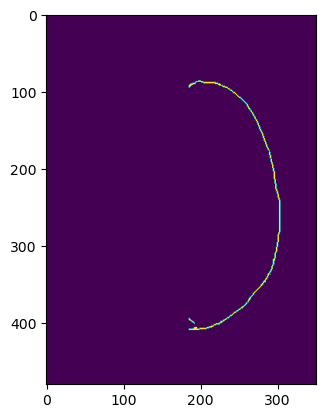

In [3]:
from pedsilicoICH.lesion_definition import insert_dural_3D # has been ported to pedsilicoICH.lesion_definition.insert_dural_3D

# need to add # of slices for hemorrhage or make it a pseudorandom option

slice_num = 150
hemorrhage_mask = insert_dural_3D(spacing=(phantom.dz, phantom.dx, phantom.dy),
                                  volume=HU_volume,
                                  dura_map=dura_map, init_slice=slice_num,
                                  hematoma_type='epidural')

HU_volume[hemorrhage_mask==1] = 70 # set lesion to 60 HU

if save_output:
    save_img = nib.Nifti1Image(hemorrhage_mask.transpose(2, 1, 0), img.affine)
    nib.save(save_img, 'test_hemorrhage_mask.nii')

    HU_img = nib.Nifti1Image(HU_volume.transpose(2, 1, 0), img.affine)
    nib.save(HU_img, 'test_HU_hemorrhage.nii')

Visualize results (for demo, scroll to slices 95-105)

In [4]:
scrollview(HU_volume)

interactive(children=(IntSlider(value=240, description='idx', max=479), Output()), _dom_classes=('widget-inter…